# Name
Please write your name down here:

Peter Brederlow

**Supervised learning on mice phenotype data**

Predicting diet from differential expression data was easy with SVMs. It was very neat and regular data, no cells were missing, all values were in a similar range, etc. We will now use a different dataset: the phenotype tables from days 3/4.

In [2]:
from sklearn.experimental import enable_iterative_imputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, recall_score, matthews_corrcoef, classification_report
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Data Loading & Preprocessing
Since the phenotype data has a lot of missing values which we don't want to deal with *too* much, we wrote some code to remove samples with a very large number of missing values, and also some features. Our data still has some missing values, but not so much to compromise our models anymore.

In [3]:
phenotype = pd.read_excel(
     'https://raw.githubusercontent.com/Practical-Integrative-Bioinformatics/Introduction/main/data/phenotype.xlsx',
    #'../../data/phenotype.xlsx',
    sheet_name=None, 
    na_values='x', 
    index_col='@format=column'
)

/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-pa

In [4]:
# The VO2Max table doesn't follow their own column naming conventions, so fix that first
def rename_vo2_cols(colname):
    return colname.replace('CD', 'CD_').replace('HFD', 'HFD_').replace('__', '_')

phenotype['VO2Max'].rename(columns=rename_vo2_cols, inplace=True)

def split_cd_hfd(input_df):
    input_df.index.name = 'strain'  # change that weird @format=column Excel index label to something meaningful
    input_cd = input_df.filter(regex=r'_CD|CD_') # loc[:, (input_df.columns.str.contains('CD_')) | (input_df.columns.str.contains('_CD'))]
    input_hfd = input_df.filter(regex=r'_HFD|HFD_') #loc[:, (input_df.columns.str.contains('HFD_')) | (input_df.columns.str.contains('_HFD'))]

    input_cd.columns = input_cd.columns.str.replace(r'_CD|CD_', '', regex=True)
    input_hfd.columns = input_hfd.columns.str.replace(r'_HFD|HFD_', '', regex=True)
    
    input_cd.insert(0, 'diet', 'CD')
    input_hfd.insert(0, 'diet', 'HFD')
    
    kept_columns = input_cd.columns.intersection(input_hfd.columns)
    
    df_both = pd.concat([input_cd, input_hfd], sort=False)[kept_columns]
    df_both.columns.name = 'experiment'  # added only later
    
    return df_both.reset_index().set_index(['strain', 'diet']).sort_index()

In [5]:
pheno = pd.concat([split_cd_hfd(sheet) for sheet_name, sheet in phenotype.items() if sheet_name != "NEW"], axis=1)

# let's remove the main offenders for missing values, both samples and features
pheno = pheno.loc[pheno.T.isna().sum() < 42]  # samples with lots of missing features
pheno = pheno.loc[:, pheno.isna().sum() < 11]  # features with still too many missing values

# a peek at what missing data we are left with:
# sns.clustermap(pheno.isna(), figsize=(10,10))

We will now cut out some features that would make things too easy for our SVM. Bodyweight-associated and food intake features will be banned from our feature list.

/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


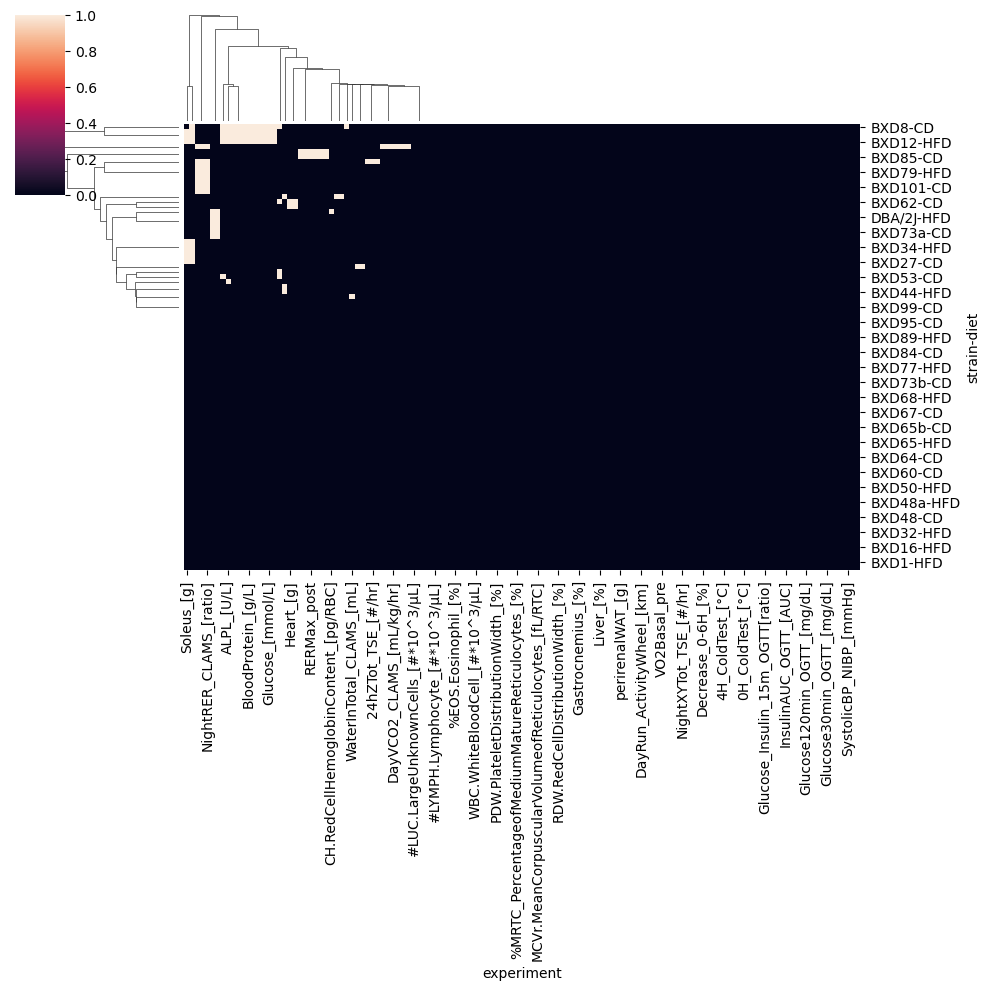

In [6]:
banned = ["KNOWN_BATCH_EFFECT_BY_COHORT_ORDER", "BWGain", "Mass", "BodyWeight", "Food", "Sacrifice"]
kept_cols = [x for x in pheno.columns if all(b not in x for b in banned)]

data_raw = pheno.loc[:, kept_cols]  # unlike the expression table, the phenotype table already has samples as rows so no transposing needed
target = data_raw.index.to_frame()['diet'].replace({'CD': 0, 'HFD': 1})

# let's look at the structure of missing values
sns.clustermap(data_raw.isna())
plt.show()

## Impute missing values

Since most ML algorithms can't deal with NaN values, we will first impute them with the rather primitive `SimpleImputer` class of `sklearn`. Our only choice is whether to use a constant value, the column mean or the column median for the missing values. We will go with median.

Imputer classes have a `fit`, `transform` and `fit_transform` method. Figure out which one you need to fill those missing values.

Unfortunately, SimpleImputer always returns numpy matrices instead of DataFrames, so you should convert the results back to a DF with the correct row/column indices.

/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/seaborn/matrix.py:615: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, max_dependent_coord * 1.05)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/seaborn/matrix.py:623: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_dependent_coord * 1.05)


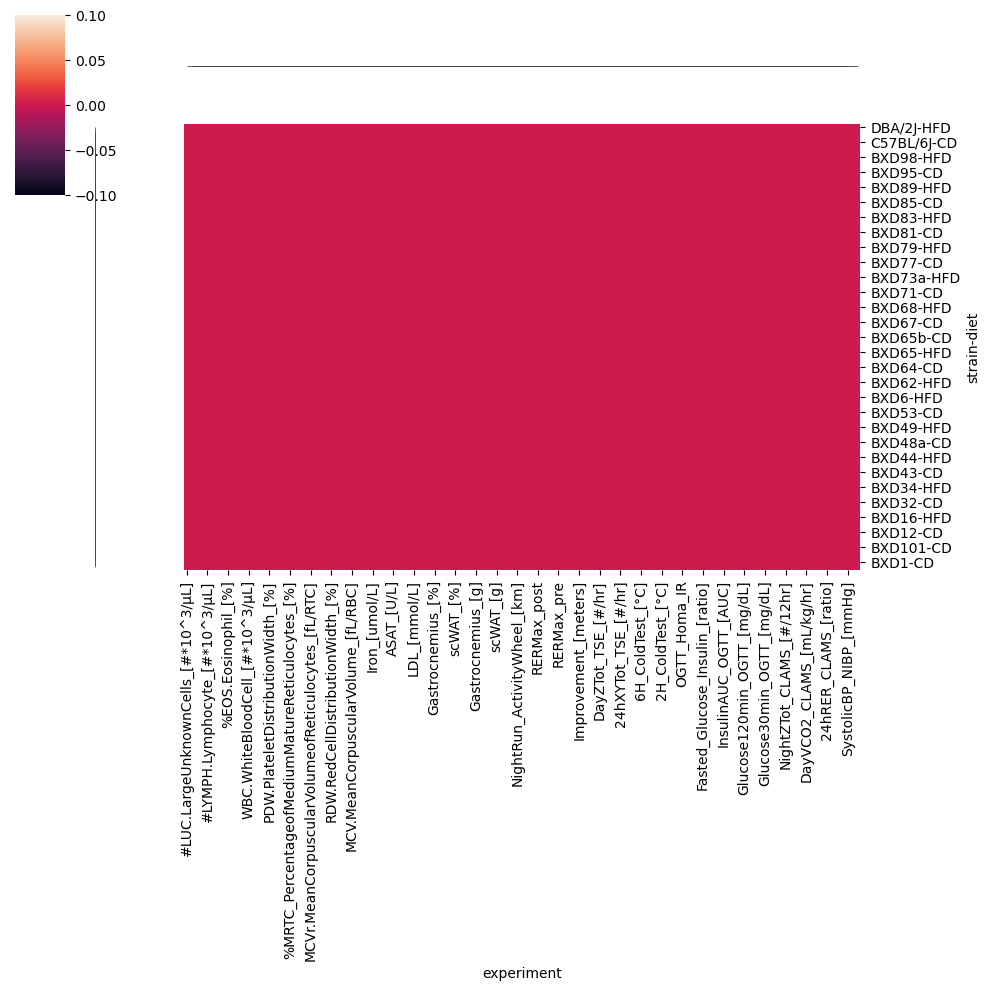

In [7]:
# imputer = SimpleImputer(...)

# data = pd.DataFrame(..., index=data_raw.index, columns=data_raw.columns)

# YOUR CODE HERE
imputer = SimpleImputer(strategy='median')
data_imputed = pd.DataFrame(imputer.fit_transform(data_raw), index=data_raw.index, columns=data_raw.columns)
sns.clustermap(data_imputed.isna())
plt.show()

## Look at the value ranges of different features. Standardize the data
`data.describe()` can give you an overview of the means, standard deviations, etc. of the different features. If you take a close look at the `mean` or `max` row, you will see that they span 6-7 orders of magnitude, which isn't desirable when using certain machine learning methods, especially linear ones. A PCA would essentially ignore features with small values in favour of features with large values, but SVM's would struggle with them as well.

We should standardize our data so that the scales of different features become comparable. For reasons to be clarified later, we will use the `StandardScaler` class instead of our good old pandas one-liner. It has a similar interface to the previously used `SimpleImputer`: the methods `fit`, `transform` and `fit_transform` are available here as well.

In [8]:
# scaler = StandardScaler()
# data_std = pd.DataFrame(..., index=data.index, columns=data.columns)

# YOUR CODE HERE
data_imputed.describe()

experiment,BWLoss_AfterExercise_[%],DiastolicBP_NIBP_[mmHg],SystolicBP_NIBP_[mmHg],HeartRate_NIBP_[bpm],DayRER_CLAMS_[ratio],NightRER_CLAMS_[ratio],24hRER_CLAMS_[ratio],DayVO2_CLAMS_[mL/kg/hr],NightVO2_CLAMS_[mL/kg/hr],24hVO2_CLAMS_[mL/kg/hr],...,%MONO.Monocyte_[%],%EOS.Eosinophil_[%],%BASO.Basophil_[%],%LUC.LargeUnknownCells_[%],#NEUTR.Neutrophil_[#*10^3/µL],#LYMPH.Lymphocyte_[#*10^3/µL],#MONO.Monocyte_[#*10^3/µL],#EOS.Eosinophil_[#*10^3/µL],#BASO.Basophil_[#*10^3/µL],#LUC.LargeUnknownCells_[#*10^3/µL]
count,89.000000,89.00000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,...,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000
mean,6.204878,79.37041,108.190054,682.886891,0.778249,0.811412,0.797451,2492.766322,2924.517524,2741.590607,...,2.269697,4.171831,0.151997,1.012843,0.962946,5.659346,0.159172,0.290011,0.016225,0.080860
std,6.634703,9.95009,8.107149,41.215783,0.040135,0.056914,0.049297,322.167783,384.337298,357.692671,...,1.011577,4.519580,0.082439,1.145023,0.560520,2.632939,0.093617,0.457211,0.037971,0.099476
min,-6.704486,58.00000,89.400000,584.000000,0.640000,0.654000,0.649000,1716.000000,1935.000000,1832.000000,...,0.800000,0.780000,0.025000,0.100000,0.190000,1.620000,0.030000,0.040000,0.000000,0.000000
25%,1.932949,73.80000,103.200000,657.000000,0.752180,0.773600,0.767000,2312.000000,2653.504000,2502.000000,...,1.500000,2.050000,0.100000,0.370000,0.592000,3.880000,0.090000,0.140000,0.000000,0.020000
50%,5.500290,78.87500,107.750000,680.959000,0.776800,0.800000,0.784000,2494.000000,2932.500000,2742.000000,...,2.100000,3.050000,0.140000,0.700000,0.810000,5.500000,0.130000,0.200000,0.010000,0.050000
75%,9.630268,84.62500,113.000000,706.250000,0.800275,0.851600,0.834000,2646.000000,3125.000000,2926.768000,...,2.920000,4.650000,0.200000,1.250000,1.190000,6.670000,0.210000,0.275000,0.020000,0.105000
max,25.909315,105.50000,128.800000,792.800000,0.882850,0.932750,0.912800,3643.000000,4250.000000,4027.000000,...,6.400000,30.750000,0.500000,8.900000,3.010000,15.820000,0.480000,3.950000,0.300000,0.690000


In [9]:
standard_scaler = StandardScaler()
data_std = pd.DataFrame(standard_scaler.fit_transform(data_imputed), index=data_imputed.index, columns=data_imputed.columns)
data_std.describe()

experiment,BWLoss_AfterExercise_[%],DiastolicBP_NIBP_[mmHg],SystolicBP_NIBP_[mmHg],HeartRate_NIBP_[bpm],DayRER_CLAMS_[ratio],NightRER_CLAMS_[ratio],24hRER_CLAMS_[ratio],DayVO2_CLAMS_[mL/kg/hr],NightVO2_CLAMS_[mL/kg/hr],24hVO2_CLAMS_[mL/kg/hr],...,%MONO.Monocyte_[%],%EOS.Eosinophil_[%],%BASO.Basophil_[%],%LUC.LargeUnknownCells_[%],#NEUTR.Neutrophil_[#*10^3/µL],#LYMPH.Lymphocyte_[#*10^3/µL],#MONO.Monocyte_[#*10^3/µL],#EOS.Eosinophil_[#*10^3/µL],#BASO.Basophil_[#*10^3/µL],#LUC.LargeUnknownCells_[#*10^3/µL]
count,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,...,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01
mean,-8.482603e-17,-2.780235e-16,-4.748075e-16,2.744683e-15,-2.754819e-15,-2.826703e-15,-8.532501e-16,6.056329e-16,5.239255e-17,-1.216256e-16,...,3.729850e-16,-7.796510e-17,-2.357665e-16,9.979533e-18,3.243348e-17,-1.434558e-16,7.547022e-17,-1.953805e-16,6.798557e-17,-8.233115e-17
std,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,...,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00
min,-1.956758e+00,-2.159929e+00,-2.330846e+00,-2.412842e+00,-3.464152e+00,-2.781429e+00,-3.028404e+00,-2.424722e+00,-2.589194e+00,-2.557347e+00,...,-1.461109e+00,-7.547269e-01,-1.549220e+00,-8.017435e-01,-1.386794e+00,-1.542851e+00,-1.387613e+00,-5.499162e-01,-4.297101e-01,-8.174637e-01
25%,-6.475246e-01,-5.630070e-01,-6.190001e-01,-6.316406e-01,-6.532192e-01,-6.681216e-01,-6.211959e-01,-5.642728e-01,-7.091402e-01,-6.736176e-01,...,-7.651992e-01,-4.721353e-01,-6.343018e-01,-5.646043e-01,-6.655385e-01,-6.796314e-01,-7.430708e-01,-3.299596e-01,-4.297101e-01,-6.152702e-01
50%,-1.067992e-01,-5.007158e-02,-5.458722e-02,-4.704058e-02,-3.630733e-02,-2.016391e-01,-2.743947e-01,3.850997e-03,2.088713e-02,1.151024e-03,...,-1.687051e-01,-2.496222e-01,-1.463457e-01,-2.747676e-01,-2.744100e-01,-6.086327e-02,-3.133759e-01,-1.979857e-01,-1.648611e-01,-3.119800e-01
75%,5.192090e-01,5.310868e-01,5.966584e-01,5.700602e-01,5.519138e-01,7.101221e-01,7.456088e-01,4.783280e-01,5.245870e-01,5.206329e-01,...,6.465036e-01,1.063988e-01,5.855885e-01,2.082936e-01,4.073736e-01,3.860248e-01,5.460139e-01,-3.301828e-02,9.998795e-02,2.440521e-01
max,2.986732e+00,2.640944e+00,2.556598e+00,2.681882e+00,2.621024e+00,2.144026e+00,2.353134e+00,3.590522e+00,3.468288e+00,3.613975e+00,...,4.106170e+00,5.913990e+00,4.245259e+00,6.927236e+00,3.672758e+00,3.880919e+00,3.446454e+00,8.050385e+00,7.515761e+00,6.158212e+00


## Create a PCA pairplot from the standardized and non-standardized data

Do you agree that feature standardization had a beneficial effect on the PCA transformation? Coloring the data based on diet might help you with your answer.

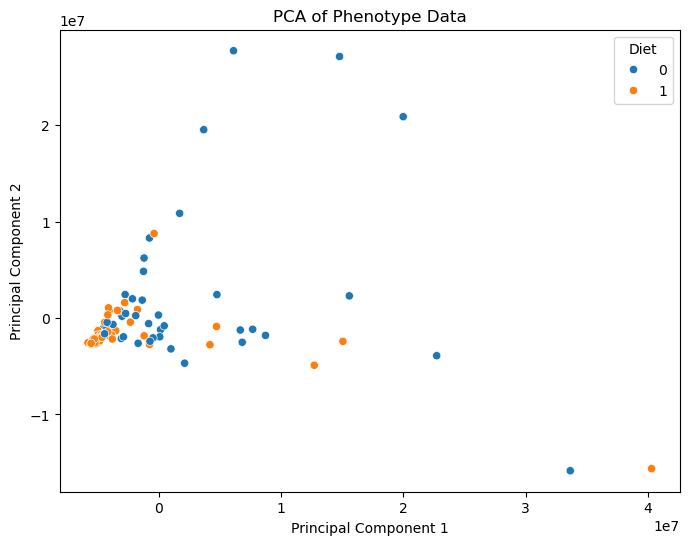

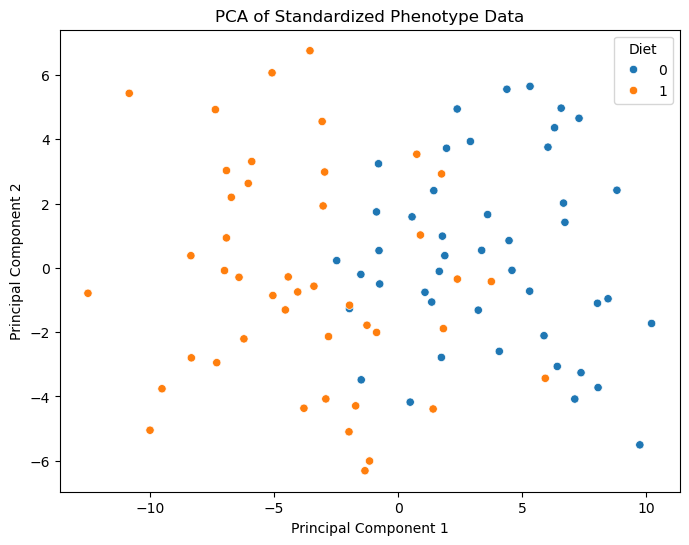

In [10]:
# non-standardized: data
# standardized: data_std

# YOUR CODE HERE
PCA_model = PCA(n_components=2)
pca = PCA_model.fit_transform(data_imputed)
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca[:, 0], y=pca[:, 1], hue=target)
plt.title('PCA of Phenotype Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Diet')
plt.show()

pca_std = PCA_model.fit_transform(data_std)
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_std[:, 0], y=pca_std[:, 1],hue=target)
plt.title('PCA of Standardized Phenotype Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Diet')
plt.show()

We can see, that variance patterns in the data get removed, making the distribution of the points under both diet approximately gaussian. Before the standardization, some few outliers demonstrated the distribution.

# Use an SVC to predict diet from non-standardized phenotype data
Try the `rbf` kernel for a change, and use 3-fold stratified cross-validation to calculate the accuracy. Don't bother with looping over the different training/testing splits manually, use the convencience function `cross_val_score`. It shouldn't take more than 3 short lines of code, or 1 longish line.

Make sure to use the non-standardized `data` DataFrame. Watch out, don't try to run a linear SVM, because it will take a long time to reach convergence and you might have to kill your notebook. Use `kernel='rbf'`.

In [11]:
# YOUR CODE HERE
target = target.astype(int)  
svc = SVC(kernel='rbf', random_state=42)
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=5, random_state=42)
scores = cross_val_score(svc, data_imputed, target, cv=rskf)

print(f"Fold accuracies: {scores}")
print(f"Mean CV accuracy: {np.mean(scores):.3f}")
print(f"Std CV accuracy: {np.std(scores):.3f}")

Fold accuracies: [0.56666667 0.63333333 0.65517241 0.7        0.73333333 0.62068966
 0.6        0.76666667 0.65517241 0.66666667 0.66666667 0.75862069
 0.7        0.83333333 0.65517241]
Mean CV accuracy: 0.681
Std CV accuracy: 0.067


## Try the same on the standardized `data_std` DataFrame.
**How does the RBF SVM perform on the standardized data?**

In [12]:
# YOUR CODE HERE
svc = SVC(kernel='rbf', random_state=42)
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=5, random_state=42)
scores = cross_val_score(svc, data_std, target, cv=rskf)
#print(f"Fold accuracies: {scores}")
print(f"Mean CV accuracy: {np.mean(scores):.3f}")
print(f"Std CV accuracy: {np.std(scores):.3f}")

Mean CV accuracy: 0.971
Std CV accuracy: 0.035


One can clearly see, that the non gaussian shape of the unstandardized data made it impossible for the SVM to fit a proper decision boundary, After the standardization, the data roughly shows a random distribution in the PCA space. Because of that the rbf kernel, which is defined like this:  
$$ k(\mathbf{x}, \mathbf{x}') = \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\sigma^2}\right) $$

This models the difference between the high dimensional gaussian distributions of the data, hence if the groups show gaussians in high dimensional space, that differ in their location, the data is as well separable as here.



## Try a linear kernel SVM on the standardized `data_std`
    
Again, just a simple `cross_val_score`. Scikit-learn makes it very easy to test different models with tiny modifications to your code.

In [13]:
# YOUR CODE HERE
svc = SVC(kernel='linear', random_state=42)
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=5, random_state=42)
scores = cross_val_score(svc, data_std, target, cv=rskf)
#print(f"Fold accuracies: {scores}")
print(f"Mean CV accuracy: {np.mean(scores):.3f}")
print(f"Std CV accuracy: {np.std(scores):.3f}")

Mean CV accuracy: 0.987
Std CV accuracy: 0.021


## Standardize the data fold-by-fold

When we standardized the entire dataset in one go, we cheated a bit. We did not keep the training and testing data fully independent. For a truly honest evaluation, we should derive the standardization parameters (column mean & standard deviation) from the training data only, and apply the same transformation to the test data before prediction. The test data should NOT influence how the training data gets standardized.

You will (temporarily) have to give up on the convenience functions, as you have an extra standardization step to do before fitting and predicting in each fold. Use `StandardScaler`'s `fit_transform` on the training data, and `transform` on the testing data.

**Did it influence the accuracy?**

In [14]:
# YOUR CODE HERE
fold_accuracies = []
for train_idx, test_idx in rskf.split(data_imputed, target):
    X_train = data_imputed.iloc[train_idx]
    X_test = data_imputed.iloc[test_idx]
    y_train = target.iloc[train_idx]
    y_test = target.iloc[test_idx]

    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_test_std = scaler.transform(X_test)

    svc = SVC(kernel='linear', random_state=42)
    svc.fit(X_train_std, y_train)
    fold_accuracies.append(svc.score(X_test_std, y_test))
    
fold_accuracies = np.array(fold_accuracies)
print(f"Mean CV accuracy (fold-by-fold standardization): {fold_accuracies.mean():.3f}")
print(f"Std CV accuracy (fold-by-fold standardization): {fold_accuracies.std():.3f}")

Mean CV accuracy (fold-by-fold standardization): 0.980
Std CV accuracy (fold-by-fold standardization): 0.024


The accuracy was minimally worse, but this tradeoff can definitely be taken in order to standardize the data properly.

Accuracy usually changes only slightly with proper fold-by-fold standardization, but this approach is the correct unbiased evaluation. Compare the two printed mean accuracies above: any gap is the amount of optimistic bias introduced by global standardization.

## Standardize inside the convenience functions
`sklearn` helps us string together steps by combining them into `Pipeline` objects. We can combine a standardization and a prediction method into a single, indivisible unit, and `sklearn` will make sure that they never violate the principle of keeping the training and testing stages separate, and always uses the appropriate interfaces at every stage.

Those with a keen eye may realize that we cheated the same way when we imputed missing data. You can therefore add the imputation step to the pipeline as well (not that it would change much given how few values had to be imputed).

Once you have created the pipeline, you can pass it to the convenience function `cross_val_score` just like you passed standalone SVC models before.

In [15]:
# YOUR CODE HERE
pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', random_state=42))
])

rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=5, random_state=42)
scores = cross_val_score(pipe, data_raw, target, cv=rskf)
print(f"Mean CV accuracy: {np.mean(scores):.3f}")
print(f"Std CV accuracy: {np.std(scores):.3f}")

Mean CV accuracy: 0.946
Std CV accuracy: 0.032


## Take a closer look at the most important features

In the previous notebook we extracted feature weights from linear SVMs by accessing a fitted SVM's `.coef_` attribute. We should do the same now, and take a look at the features that the linear SVM assigned the largest weights to.

Train a `linear` SVM with the entire standardized dataset and extract the features with the 5 highest absolute coefficients. Visualize their values using a `pairplot` and color the samples with their diet.

**What phenotypic traits came out on top? Can you think of an explanation why they would be affected by diet?**

In [16]:
# YOUR CODE HERE
data = data_std.copy()
svc = SVC(kernel='linear', random_state=42)
svc.fit(data, target)
coefs = svc.coef_[0]
feature_importance = pd.Series(coefs, index=data.columns).sort_values(key=abs, ascending=False)
print(feature_importance.head(5))



experiment
RERBasal_post                      -0.190478
NightRER_CLAMS_[ratio]             -0.127135
RERMax_post                        -0.126645
RDW.RedCellDistributionWidth_[%]    0.115145
24hRER_CLAMS_[ratio]               -0.103132
dtype: float64


The most important features to distinguish seem to be features related to the respiratory exchange rate, which describes the ratio of oxygen consumed and CO2 produced, as well as the red blood cell disstribution, that probably also influeces the RER.

## Exclude some more features

For the upcoming tasks, we want an imperfect model for demonstration purposes. So we'll cut out the 10 best features to reduce the accuracy of the model. Please keep using `data2` or `data2_std` from now on. You can also experiment with removing even more features.

Quickly check how well an SVM performs on this data.

In [17]:
# YOUR CODE HERE
top10_features = feature_importance.head(10).index
data2 = data.drop(columns=top10_features)
scores = cross_val_score(pipe, data2, target, cv=rskf)
print(f"Mean CV accuracy: {np.mean(scores):.3f}")
print(f"Std CV accuracy: {np.std(scores):.3f}")

Mean CV accuracy: 0.878
Std CV accuracy: 0.033


## Sensitivity, specificity, precision...

In some cases, the accuracy of a prediction is secondary to other quality metrics, such as sensitivity or specificity. For example, HIV sceening tests are optimized for sensitivity at the expense of accuracy, ensuring that almost no HIV-positive individuals test negative. This results in an HIV-scare for a lot of HIV-negative individuals each year (as higher sensitivity always implies a higher false positive rate) but in exchange no case of HIV goes undetected on a screening.

We can tune most ML models similarly, and sacrifice accuracy for higher sensitivity or specificity. But first, simply report the sensitivity of your SVM for detecting a high-fat diet (label `1`). You will find tools in `sklearn` that help you calculate this value. Hint: "recall" is a synonym for sensitivity. All the other synonyms and definitions can be found here https://en.wikipedia.org/wiki/Precision_and_recall#Definition_(classification_context)

Make use of the convenience function `cross_val_predict`! It's similar to `cross_val_score`, but instead of returning the accuracies of individual folds, it takes the predicted labels in each fold, and merges + sorts them to match the original order of your samples. This way it guarantees that every prediction comes from a proper cross-validation fold, and the predictions are directly comparable to the target labels.

Sidenote: Feel free to continue with the globally standardized `data2_std` for if you are uncomfortable with the `Pipeline` object.

In [18]:
# YOUR CODE HERE
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scores = cross_val_predict(pipe, data2, target, cv=skf)
sensitivity = recall_score(target, scores, pos_label=1)
print(f"Sensitivity for HFD: {sensitivity:.3f}")

Sensitivity for HFD: 0.977


## Make your SVM 95+ percent sensitive for HFD
You can adjust the SVM's parameters to increase your sensitivity for mice on an HFD diet. The `class_weight` keyword of `SVC` takes a dictionary with label-weight pairs (ideally with weights summing to 1).

**How did it affect the overall accuracy, and the false positive rate (i.e. sensitivity for the other, CD condition)? You can create an overview with `classification_report`.**

In [19]:
# YOUR CODE HERE
eval_report = classification_report(target, scores, target_names=['CD', 'HFD'])
print("Classification Report:\n", eval_report)

Classification Report:
               precision    recall  f1-score   support

          CD       0.97      0.84      0.90        45
         HFD       0.86      0.98      0.91        44

    accuracy                           0.91        89
   macro avg       0.92      0.91      0.91        89
weighted avg       0.92      0.91      0.91        89



## ROC curves
We are often interested the relationship between the model's accuracy and sensitivity, or a more commonly used pair of quality measures: false positive rate vs. sensitivity (aka true positive rate). This is what ROC (receiver operating characteristic) curves display: the trade-off between these two qualities.

In the previous task, you used class weights (used during training) to tune sensitivity. An alternative way is "shifting" the decision boundary before producing the output labels.

Most classification ML methods, despite their categorical output, use continuous internal variables for their predictions, and their final decision is a simple thresholding of this continuous variable. For example, in the case of SVMs, this variable is the data point's signed distance from the separating boundary: positive values are assigned to one class, negative values to the other class. Values close to zero (= close to the boundary) are harder to confidently place in either class, and it's down to the arbitrary threshold how they end up being predicted.

You can create a ROC curve by testing how the choice of threshold affects false positive rate and sensitivity. Needless to say, `sklearn` helps you create such plots. All you need to do is extract the SVM's continuous predictive variables, pass it to the appropriate function with the target labels, and plot the results.

Hint: SVC's can return these continuous internal variables if you call `.decision_function(...)` instead of `.predict(...)`. The convenience function `cross_val_predict` gathers the values returned by the classifier's `predict` function by default, but you can change its behaviour with the `method` keyword.

Optional: you can try to plot several ROC curves on top of each other, each resulting from a different shuffled cross-validation run.

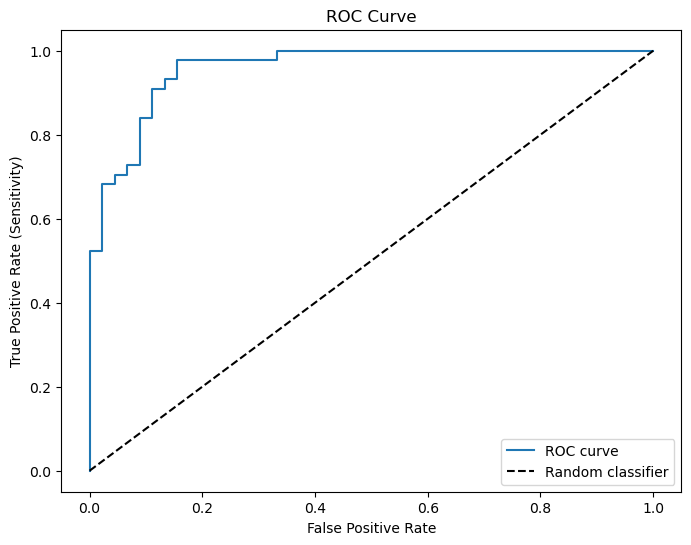

In [20]:
# YOUR CODE HERE
decision_scores = cross_val_predict(pipe, data2, target, cv=skf, method='decision_function')
fpr, tpr, thresholds = roc_curve(target, decision_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.legend()
plt.show()

An alternative internal variable: estimated probability. It has to be turned on manually when initializing the `SVC` with `probability=True`, and it will slow things down a bit. The probability values can be accessed by calling `.predict_proba(...)`. In this case you can call `cross_val_predict(..., method='predict_proba')`.

Watch out, `predict_proba` returns two values, the probabilies for either class, summing to one. You are interested in the second value, which is the probability of your `1` label (HFD).

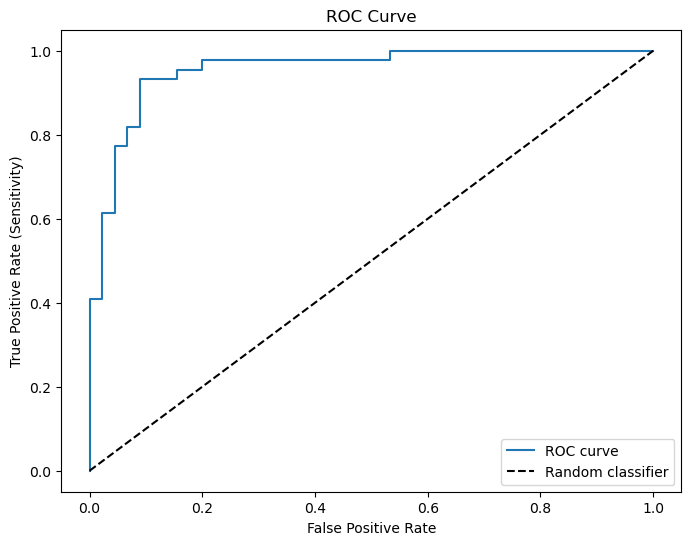

In [21]:
# YOUR CODE HERE
pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear', random_state=65, probability=True))
])
decision_scores = cross_val_predict(pipe, data2, target, cv=skf, method='predict_proba')[:, 1]
fpr, tpr, thresholds = roc_curve(target, decision_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Find the threshold for the desired sensitivity / FPR tradeoff
[You increased sensitivity for HFD](#Make-your-SVM-95+-percent-sensitive-for-HFD) (label 1) by telling the SVM to use a higher weight for that class. Since then, you have learned that you could have instead used the SVM's continuous predictive variables, and threshold them to your own liking, instead of leaving it to the SVM's default (0 for `decision_function` and 0.5 for `predict_proba`).

Your task is to find the threshold value (`decision_function` or `predict_proba`, whichever you prefer) that would achieve 95% sensitivity. Remember, the `roc_curve` function returned three vectors: the ROC plot's FPR values, sensitivity values and the threshold that corresponded to them.

<div class="alert alert-block alert-info"><b>Hint: </b> iterate over the sensitivity and threshold values together, and report the first threshold where sensitivity exceeds 0.95. You can iterate over two lists together using Python's <code>zip</code> function.</div>

In [22]:
# YOUR CODE HERE
for sens, thresh in zip(tpr, thresholds):
    if sens >= 0.95:
        print(thresh)
        break

0.24579709158488808
